# 04 Alex Implementation: Static Band + TWAP/VWAP Delta Hedging

This notebook is my own implementation of the `JPM_Optimal_Intraday_Delta_Hedging_v4`
proposal (`docs/JPM_Optimal_Intraday_Delta_Hedging__v2_.pdf` in this repo is the v2 draft;
this notebook follows the v4 static-band baseline). It reuses the team's Step 0 data
artifacts (`data/simulated/simulated_executed_trades.csv`, the synthetic ES option
trade-flow tape, and `data/processed/market_inputs_2026.csv`, the cleaned 5-minute
ES/SPX/SPY/BVOL/SOFR panel) but implements the hedging engine itself from scratch,
built directly off the proposal's equations rather than `02_baseline_strategies.ipynb`.

Three places where this implementation departs from `02_baseline_strategies.ipynb` --
the first two traced back to the proposal text, the third a deliberate refinement of it:

1. **Unit convention (Eq. 11).** The proposal is explicit that the ES futures
   multiplier must *not* be applied when converting an option trade into its book-delta
   contribution, because an ES option's delta is already expressed in ES-futures-contract
   equivalents (both instruments share the same $50 multiplier, so it cancels). The
   shared baseline notebook multiplies by `ES_MULTIPLIER` a second time, which inflates
   every book-delta figure 50x. This notebook follows Eq. 11 literally: no multiplier at
   the delta-arrival stage.
2. **Continuous book-delta revaluation (Eq. 17-19).** The proposal defines
   `Delta_book(t_j)` as the sum of *all live option deltas repriced at the current bar's
   ES price*, not a running sum of deltas frozen at each trade's own execution price. The
   "Practical rule" box on p.8 says this explicitly: the model recomputes book delta from
   scratch at every 5-minute step. That is also the only way to reproduce the smooth,
   continuously-drifting Zero Hedge curve in the proposal's example figure (p.13) -- a
   frozen-delta cumulative sum only moves at trade arrivals and would look like a step
   function, not a drift. This notebook recomputes Black-76 deltas for the whole live book
   at every bar.
3. **Closing-auction execution cost (refinement of Eq. 12-16).** The proposal costs every
   hedge fill with the same spread + impact formula, which overstates the cost of trading
   into the close: the cash-close settlement window concentrates roughly 7x an average
   bar's ES volume into a single auction-style print. Any fill landing on the last bar of
   the day (the forced end-of-day flatten, a child slice whose schedule runs into the
   close, or Full Hedge's final rebalance) is therefore costed as a closing-auction
   execution: zero bid/ask spread and an impact coefficient scaled by
   `CLOSE_IMPACT_FACTOR = 0.15` (sqrt-impact depth scaling against the ~7x deeper close,
   times a haircut for the temporary-impact share an auction cross does not pay).

Everything else -- the static band with breach buffer and cooldown (Eq. 1-6), TWAP/VWAP
execution (Eq. 7-10), the execution-cost proxy (Eq. 12-16, with the closing-auction
refinement above), and the realized residual-delta risk measure (Eq. 21-23) -- is
implemented directly from the proposal's equations.

**Scope:** this notebook implements the engine and runs the backtest (benchmarks + full
grid search), persisting four artifacts:

- `data/processed/alex_book_delta_paths.csv` -- the revalued book delta at every 5-minute bar;
- `outputs/tables/alex_benchmark_results.csv` -- Zero Hedge / Full Hedge aggregates;
- `outputs/tables/alex_grid_results.csv` -- aggregate results per grid configuration;
- `data/processed/alex_hedge_events.csv` -- the full hedge-trade log for every configuration.

All evaluation -- the standardized cost-risk objective and theta* selection (Eq. 24-28),
the efficient frontier, sensitivity analysis, the intraday walk-through, and the final
recommendation -- lives in `03_strategy_comparison.ipynb`, which consumes these artifacts.

In [1]:
from pathlib import Path
import itertools
import time

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
SIM_DIR = DATA_DIR / "simulated"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_TABLE_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURE_DIR = PROJECT_ROOT / "outputs" / "figures"
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXECUTED_TRADES_PATH = SIM_DIR / "simulated_executed_trades.csv"
MARKET_INPUTS_PATH = PROCESSED_DIR / "market_inputs_2026.csv"

ES_MULTIPLIER = 50.0  # M_h -- dollars per ES futures index point
BAR_MINUTES = 5

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\chung\Downloads\JPM delta hedging project\JPM_Optimal_Intraday_Delta_Hedging_Strategy


## 1. Load Executed Option Trade Flow and Market Inputs

`simulated_executed_trades.csv` is the synthetic ES-option execution tape (Section
"Option Trade-Flow Simulation" of the proposal): each row is one option print with side,
quantity, strike, option type, expiry, and the option's own bid/ask at execution.
`market_inputs_2026.csv` is the cleaned 5-minute ES/SPX/SPY panel with the flat 1M BVOL
and SOFR OIS inputs used for pricing, produced by `01_data_simulation.ipynb`.

In [2]:
def load_executed_trades(path: Path) -> pd.DataFrame:
    trades = pd.read_csv(path)
    trades["timestamp_utc"] = pd.to_datetime(trades["timestamp"], utc=True)
    trades["timestamp_et"] = trades["timestamp_utc"].dt.tz_convert("America/New_York").dt.tz_localize(None)
    trades["trade_date"] = trades["timestamp_et"].dt.normalize()
    trades["expiry_date"] = pd.to_datetime(trades["expiry_date"])
    trades["bar_time"] = trades["timestamp_et"].dt.floor(f"{BAR_MINUTES}min")
    trades["side"] = trades["side"].str.upper()
    trades["opt_type"] = trades["opt_type"].str.upper()
    return trades.sort_values("timestamp_et").reset_index(drop=True)


def load_market_inputs(path: Path) -> pd.DataFrame:
    market = pd.read_csv(path)
    market["timestamp_et"] = pd.to_datetime(market["timestamp_et"])
    market["trade_date"] = pd.to_datetime(market["trade_date"])
    return (
        market.sort_values("timestamp_et")
        .reset_index(drop=True)
        .rename(columns={"timestamp_et": "bar_time"})
    )


trades = load_executed_trades(EXECUTED_TRADES_PATH)
market = load_market_inputs(MARKET_INPUTS_PATH)

print(f"Executed option trades: {len(trades):,} across {trades['trade_date'].nunique()} trading days")
print(f"Market bars: {len(market):,} across {market['trade_date'].nunique()} trading days")
trades.head()

Executed option trades: 32,127 across 102 trading days
Market bars: 8,364 across 102 trading days


,trade_id,timestamp,sec_of_day,symbol,root,expiry_code,expiry_date,opt_type,strike,side,quantity,bid,ask,exec_price,timestamp_utc,timestamp_et,trade_date,bar_time
0,1,2026-01-02 14:42:39+00:00,52959,ESM6 P6100,ES,ESM6,2026-06-19,P,6100.0,SELL,2,95.75,96.00,95.345960,2026-01-02 14:42:39+00:00,2026-01-02 09:42:39,2026-01-02,2026-01-02 09:40:00
1,2,2026-01-02 14:48:58+00:00,53338,ESH6 C7325,ES,ESH6,2026-03-20,C,7325.0,SELL,15,19.75,20.00,20.209821,2026-01-02 14:48:58+00:00,2026-01-02 09:48:58,2026-01-02,2026-01-02 09:45:00
2,3,2026-01-02 14:52:13+00:00,53533,ESM6 P6800,ES,ESM6,2026-06-19,P,6800.0,BUY,15,225.75,226.25,220.270833,2026-01-02 14:52:13+00:00,2026-01-02 09:52:13,2026-01-02,2026-01-02 09:50:00
3,4,2026-01-02 14:53:41+00:00,53621,ESH6 C7000,ES,ESH6,2026-03-20,C,7000.0,BUY,1,104.50,104.75,112.590909,2026-01-02 14:53:41+00:00,2026-01-02 09:53:41,2026-01-02,2026-01-02 09:50:00
4,5,2026-01-02 14:53:57+00:00,53637,ESH6 P4500,ES,ESH6,2026-03-20,P,4500.0,BUY,5,4.45,4.50,4.632456,2026-01-02 14:53:57+00:00,2026-01-02 09:53:57,2026-01-02,2026-01-02 09:50:00


## 2. Delta Arrivals and the ES Unit Convention (Eq. 11)

For each option trade `i`, Eq. 11 defines its marginal book-delta contribution as
`Delta_new,i = s_i * n_i * delta_i` -- trade-direction sign times contract count times
option delta, **with no ES-futures multiplier**. `s_i` comes from side (`BUY` = +1,
`SELL` = -1), and `delta_i` will be evaluated with a Black-76 futures-option delta since
the underlying (`ES` options struck on ES futures) is a futures option, not an equity or
index option.

In [3]:
trades["side_sign"] = np.where(trades["side"].eq("BUY"), 1.0, -1.0)
trades["cp_sign"] = np.where(trades["opt_type"].eq("C"), 1, -1)
trades["dte_years"] = (trades["expiry_date"] - trades["trade_date"]).dt.days.clip(lower=1) / 365.0
trades["delta_weight"] = trades["side_sign"] * trades["quantity"]  # Eq. 11 pre-multiplier: s_i * n_i

incorrect_scale_example = (trades["delta_weight"] * ES_MULTIPLIER).abs().sum()
correct_scale_example = trades["delta_weight"].abs().sum()
print(
    f"Sum of |s_i * n_i| across the tape: {correct_scale_example:,.0f} contracts "
    f"(Eq. 11, correct unit convention)."
)
print(
    f"The same sum re-multiplied by M_h=50 as in 02_baseline_strategies.ipynb would read "
    f"{incorrect_scale_example:,.0f} -- a 50x unit-mismatch that this notebook avoids."
)
trades[["trade_id", "side", "quantity", "opt_type", "strike", "side_sign", "cp_sign", "dte_years", "delta_weight"]].head()

Sum of |s_i * n_i| across the tape: 661,367 contracts (Eq. 11, correct unit convention).
The same sum re-multiplied by M_h=50 as in 02_baseline_strategies.ipynb would read 33,068,350 -- a 50x unit-mismatch that this notebook avoids.


,trade_id,side,quantity,opt_type,strike,side_sign,cp_sign,dte_years,delta_weight
0,1,SELL,2,P,6100.0,-1.0,-1,0.460274,-2.0
1,2,SELL,15,C,7325.0,-1.0,1,0.210959,-15.0
2,3,BUY,15,P,6800.0,1.0,-1,0.460274,15.0
3,4,BUY,1,C,7000.0,1.0,1,0.210959,1.0
4,5,BUY,5,P,4500.0,1.0,-1,0.210959,5.0


## 3. Full-Book Delta Revaluation Engine (Eq. 17-19)

`Delta_book(t_j) = sum_i s_i * n_i * delta_i(t_j)` for every trade `i` executed at or
before `t_j`, with `delta_i(t_j)` a Black-76 delta repriced at bar `j`'s ES futures price,
that trading day's flat 1M BVOL, and that day's SOFR OIS rate. Because `Delta_book`
doesn't depend on the hedging strategy at all (it's just the option book's own repriced
exposure), it is computed once per trading day and reused across every strategy
configuration in the grid search below -- the expensive part of the backtest only needs
to run once.

In [4]:
def black76_delta(futures_price: np.ndarray, strike: np.ndarray, years: np.ndarray, vol: float, cp_sign: np.ndarray) -> np.ndarray:
    years = np.maximum(years, 1 / 365)
    vol = max(float(vol), 0.01)
    d1 = (np.log(futures_price / strike) + 0.5 * vol**2 * years) / (vol * np.sqrt(years))
    call_delta = norm.cdf(d1)
    return np.where(cp_sign == 1, call_delta, call_delta - 1.0)


def build_day_paths(trades: pd.DataFrame, market: pd.DataFrame) -> dict:
    day_paths = {}
    for trade_date, day_bars in market.groupby("trade_date"):
        day_bars = day_bars.sort_values("bar_time").reset_index(drop=True)
        day_trades = trades.loc[trades["trade_date"].eq(trade_date)].sort_values("bar_time").reset_index(drop=True)
        n_bars = len(day_bars)
        book_delta = np.zeros(n_bars)

        if len(day_trades) > 0:
            vol = float(day_bars["bvol_1m"].iloc[0])
            strike = day_trades["strike"].to_numpy()
            cp_sign = day_trades["cp_sign"].to_numpy()
            years = day_trades["dte_years"].to_numpy()
            weight = day_trades["delta_weight"].to_numpy()
            trade_bar_time = day_trades["bar_time"].to_numpy()
            bar_times = day_bars["bar_time"].to_numpy()
            live_count = np.searchsorted(trade_bar_time, bar_times, side="right")
            prices = day_bars["es1_price"].to_numpy(dtype=float)

            for j in range(n_bars):
                n_live = live_count[j]
                if n_live == 0:
                    continue
                deltas = black76_delta(prices[j], strike[:n_live], years[:n_live], vol, cp_sign[:n_live])
                book_delta[j] = float(np.dot(weight[:n_live], deltas))

        day_paths[trade_date] = dict(
            bar_time=day_bars["bar_time"].to_numpy(),
            es1_price=day_bars["es1_price"].to_numpy(dtype=float),
            es1_volume_5m=day_bars["es1_volume_5m"].to_numpy(dtype=float),
            es1_adv_20d=day_bars["es1_adv_20d"].to_numpy(dtype=float),
            book_delta=book_delta,
        )
    return day_paths


t0 = time.time()
day_paths = build_day_paths(trades, market)
print(f"Revalued the option book at every 5-minute bar for {len(day_paths)} trading days in {time.time() - t0:.2f}s")

Revalued the option book at every 5-minute bar for 102 trading days in 0.51s


In [5]:
OUTPUT_BOOK_DELTA_PATHS = PROCESSED_DIR / "alex_book_delta_paths.csv"

trade_counts_per_bar = trades.groupby("bar_time").size()
book_delta_paths = pd.concat(
    [
        pd.DataFrame({
            "trade_date": trade_date,
            "bar_time": p["bar_time"],
            "es1_price": p["es1_price"],
            "es1_volume_5m": p["es1_volume_5m"],
            "es1_adv_20d": p["es1_adv_20d"],
            "book_delta": p["book_delta"],
        })
        for trade_date, p in day_paths.items()
    ],
    ignore_index=True,
)
book_delta_paths["n_option_trades"] = (
    book_delta_paths["bar_time"].map(trade_counts_per_bar).fillna(0).astype(int)
)
book_delta_paths.to_csv(OUTPUT_BOOK_DELTA_PATHS, index=False)
print(f"Wrote per-bar book-delta paths to {OUTPUT_BOOK_DELTA_PATHS.relative_to(PROJECT_ROOT)} ({len(book_delta_paths):,} bars)")

Wrote per-bar book-delta paths to data\processed\alex_book_delta_paths.csv (8,364 bars)


### Why revaluation matters

The chart below contrasts, for one trading day, the frozen-delta cumulative sum (each
trade's delta fixed at its own execution price, as in `02_baseline_strategies.ipynb`)
against the continuously revalued book delta used in this notebook. The frozen version
only moves at trade arrivals and is flat in between; the revalued version keeps drifting
with the ES price even when no new option trades occur, because gamma keeps changing the
delta of the options already on the book. This is the behavior the proposal's example
intraday chart (p.13) shows for Zero Hedge.

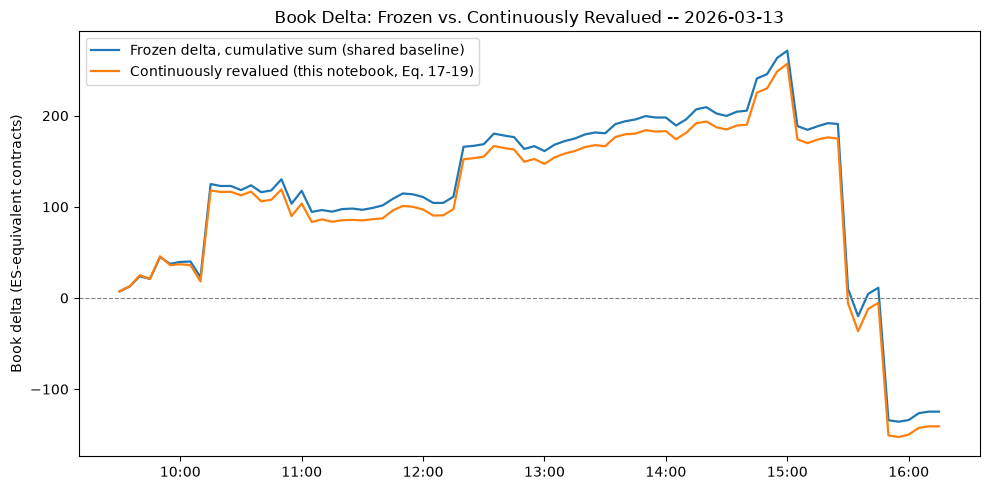

In [6]:
illustrative_date = max(day_paths, key=lambda d: len(trades.loc[trades["trade_date"].eq(d)]))
day_trades_illustrative = trades.loc[trades["trade_date"].eq(illustrative_date)].sort_values("bar_time")
day_bars_illustrative = market.loc[market["trade_date"].eq(illustrative_date)].sort_values("bar_time")

frozen_delta_by_bar = (
    day_trades_illustrative.groupby("bar_time")["delta_weight"].sum().reindex(day_bars_illustrative["bar_time"]).fillna(0.0)
)
# Frozen version uses each trade's own delta at its own execution price (no revaluation).
frozen_trade_delta = black76_delta(
    day_trades_illustrative["strike"].to_numpy() * 0
    + market.set_index("bar_time").loc[day_trades_illustrative["bar_time"], "es1_price"].to_numpy(),
    day_trades_illustrative["strike"].to_numpy(),
    day_trades_illustrative["dte_years"].to_numpy(),
    float(day_bars_illustrative["bvol_1m"].iloc[0]),
    day_trades_illustrative["cp_sign"].to_numpy(),
)
frozen_contrib = day_trades_illustrative["delta_weight"].to_numpy() * frozen_trade_delta
frozen_path = (
    pd.Series(frozen_contrib, index=day_trades_illustrative["bar_time"])
    .groupby(level=0).sum()
    .reindex(day_bars_illustrative["bar_time"], fill_value=0.0)
    .cumsum()
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(day_bars_illustrative["bar_time"], frozen_path.to_numpy(), label="Frozen delta, cumulative sum (shared baseline)", linewidth=1.6)
ax.plot(day_bars_illustrative["bar_time"], day_paths[illustrative_date]["book_delta"], label="Continuously revalued (this notebook, Eq. 17-19)", linewidth=1.6)
ax.axhline(0, color="grey", linewidth=0.8, linestyle="--")
ax.set_title(f"Book Delta: Frozen vs. Continuously Revalued -- {illustrative_date.date()}")
ax.set_ylabel("Book delta (ES-equivalent contracts)")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.legend()
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_revaluation_comparison.png", dpi=150)
plt.show()

## 4. Calibrating the No-Trade Band `H` to This Book's Scale

The proposal's example band grid (`H in {2,500, 5,000, 10,000, 20,000}`, p.3) is
illustrative, not prescriptive -- Eq. 6 explicitly treats `H` as "not assumed to be
optimal... selected through backtesting." Under the corrected Eq. 11 unit convention, the
realized book delta in this dataset is far smaller than those example values (the ES
option tape is bootstrapped from real per-trade sizes capped at 500 contracts). The
histogram below shows the distribution of each day's maximum absolute book delta; the
band grid used for the rest of this notebook is chosen to span that empirical range.

count    102.000000
mean     103.880153
std       82.028964
min       12.419093
25%       48.534853
50%       84.764604
75%      135.384619
max      608.816731
dtype: float64
Percentiles (50/75/90/95/99): [ 84.8 135.4 197.6 256.8 265.9]


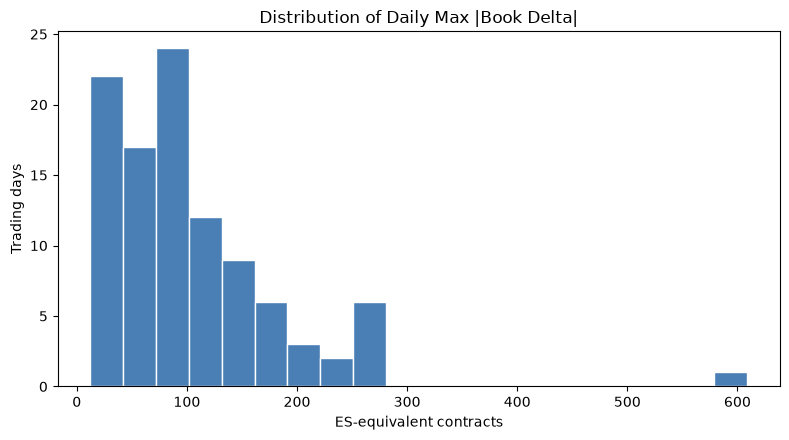


H grid (ES-equivalent contracts): [25, 50, 100, 200]


In [7]:
daily_max_abs_delta = pd.Series({d: np.max(np.abs(p["book_delta"])) for d, p in day_paths.items()})
print(daily_max_abs_delta.describe())
print("Percentiles (50/75/90/95/99):", np.percentile(daily_max_abs_delta, [50, 75, 90, 95, 99]).round(1))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(daily_max_abs_delta, bins=20, color="#4a7fb5", edgecolor="white")
ax.set_title("Distribution of Daily Max |Book Delta|")
ax.set_xlabel("ES-equivalent contracts")
ax.set_ylabel("Trading days")
fig.tight_layout()
fig.savefig(OUTPUT_FIGURE_DIR / "alex_book_delta_scale.png", dpi=150)
plt.show()

H_GRID = [25, 50, 100, 200]
EPS_GRID = [0.0, 0.05, 0.10]
COOLDOWN_GRID_MIN = [0, 15, 30]
HORIZON_GRID_MIN = [15, 30, 60]
METHOD_GRID = ["twap", "vwap"]
print(f"\nH grid (ES-equivalent contracts): {H_GRID}")

## 5. Trigger Rule, TWAP/VWAP Execution, and Execution Cost

- **Trigger with breach buffer and cooldown (Eq. 1-6 + refinement text):** hedge fires
  when `|Delta(t)| > H*(1+eps)`, unless a post-hedge cooldown of `T_cooldown` is active --
  the cooldown is overridden if the breach exceeds `2H`.
- **TWAP/VWAP execution (Eq. 7-10):** the parent order `Q_t = -Delta(t)` is split evenly
  over time (TWAP) or by expected ES futures volume share (VWAP) across the execution
  horizon `tau`.
- **Execution cost (Eq. 12-16):** `C_exec = spread cost + ADV-adjusted impact cost`. Real
  ES futures bid/ask quotes aren't available in this dataset (only OHLC/volume bars), so
  the half-spread is proxied by half of one ES tick (0.25 index points) -- a standard,
  heavily-traded front-month ES future almost always trades at the minimum tick spread.
  The impact fraction of notional is `alpha * sqrt(Q/ADV)`, and `alpha` is anchored at
  the single-contract clip: ES is extremely liquid, so a 1-lot fill should pay only
  about 0.5 bps of notional beyond the half-spread, which at the panel's median 20-day
  ES ADV (~1.17M contracts) gives `alpha = 0.5e-4 * sqrt(ADV_med) ~= 0.055` --
  effectively the proposal's illustrative `alpha = 0.05`. Size still bites through the
  sqrt term: ~1.6 bps at 10 lots, ~2.5 bps at 25 lots, ~5 bps at 100 lots. `beta = 0.5`
  follows the proposal; both parameters are swept in notebook 03's sensitivity section.
- **Closing-auction adjustment (refinement of Eq. 12-16):** the cash-close settlement
  window concentrates roughly 7x an average bar's ES volume into a single auction-style
  print (the 15:55 + 16:00 bars in this panel average ~102k contracts vs ~14.5k per bar
  overall). Costing an end-of-day fill like a continuous-session order therefore
  overstates it, so any fill landing on the last bar of the day -- the forced
  `close_flatten`, a child slice whose schedule runs into the close, or Full Hedge's
  final rebalance -- is treated as a closing-auction execution: it crosses at the auction
  clearing price (spread cost = 0) and its impact coefficient `alpha` is scaled by
  `CLOSE_IMPACT_FACTOR = 0.15` (a 1-lot close fill pays ~0.08 bps). The factor
  decomposes as sqrt-impact depth scaling against the ~7x deeper close
  (`1/sqrt(7) ~= 0.38`) times a further haircut for the temporary-impact /
  adverse-selection share of continuous-session cost that an auction cross does not pay.

In [8]:
# Impact coefficient for the ADV-adjusted square-root impact term (Eq. 12-16): the
# impact fraction of notional is alpha * sqrt(Q/ADV). alpha is anchored at the
# single-contract clip -- ES is extremely liquid, so a 1-lot fill should pay only about
# 0.5 bps of notional beyond the half-spread. At the panel's median 20-day ES ADV
# (~1.17M contracts) that gives alpha = 0.5e-4 * sqrt(ADV_med) ~= 0.055, effectively the
# proposal's illustrative 0.05. Size still bites through the sqrt term: ~1.6 bps at
# 10 lots, ~2.5 bps at 25 lots, ~5 bps at 100 lots.
IMPACT_ALPHA = 0.055
IMPACT_BETA = 0.5
ES_HALF_SPREAD = 0.125  # half of 1 ES tick (0.25 index points)
# Closing-auction liquidity: the cash-close settlement window concentrates roughly 7x an
# average bar's ES volume into a single auction-style print (the 15:55 + 16:00 bars in
# this panel average ~102k contracts vs ~14.5k per bar overall). Fills there cross at the
# auction clearing price -- no bid/ask spread, and none of the temporary-impact /
# adverse-selection cost of working a continuous-session order. Sqrt-impact depth scaling
# alone gives 1/sqrt(7) ~= 0.38; dropping the temporary-impact share takes the combined
# factor to ~0.15 (a 1-lot close fill pays ~0.08 bps). Any fill on the day's last bar
# gets this treatment: the forced close_flatten, a child slice whose schedule runs into
# the close, and Full Hedge's final rebalance.
CLOSE_IMPACT_FACTOR = 0.15


def child_order_cost(qty: float, price: float, adv: float, half_spread: float = ES_HALF_SPREAD, alpha: float = IMPACT_ALPHA, beta: float = IMPACT_BETA, at_close: bool = False):
    qty = abs(qty)
    if qty == 0.0:
        return 0.0, 0.0, 0.0
    if at_close:
        half_spread = 0.0
        alpha = alpha * CLOSE_IMPACT_FACTOR
    adv = max(adv, 1.0)
    spread_cost = ES_MULTIPLIER * qty * half_spread
    participation = qty / adv
    impact_cost = ES_MULTIPLIER * alpha * price * qty * (participation ** beta)
    return spread_cost + impact_cost, spread_cost, impact_cost


def make_schedule(parent_qty: float, start_idx: int, n_bars: int, prices: np.ndarray, volumes: np.ndarray, horizon_min: float, method: str):
    n_child = max(int(round(horizon_min / BAR_MINUTES)), 1)
    idx = np.arange(start_idx, min(start_idx + n_child, n_bars))
    if len(idx) == 0:
        return idx, np.array([])
    if method == "twap":
        weights = np.full(len(idx), 1.0 / len(idx))
    elif method == "vwap":
        vol = np.clip(volumes[idx], 0, None)
        weights = vol / vol.sum() if vol.sum() > 0 else np.full(len(idx), 1.0 / len(idx))
    else:
        raise ValueError(f"Unknown execution method: {method}")
    return idx, parent_qty * weights


def simulate_day(day: dict, H, eps, cooldown_min, horizon_min, method, full_hedge=False, zero_hedge=False, return_path=False, record_events=False):
    """One trading day, one strategy configuration (Backtest Procedure, steps 1-9)."""
    n = len(day["bar_time"])
    prices, adv, vol5, book = day["es1_price"], day["es1_adv_20d"], day["es1_volume_5m"], day["book_delta"]

    hedge_cum = 0.0
    exec_cost = spread_cost = impact_cost = 0.0
    n_triggers = 0
    total_abs_hedge = 0.0
    sched_idx, sched_qty = np.array([], dtype=int), np.array([])
    cooldown_until = -1
    resid = np.zeros(n)
    # Hedge-trade log, same event grammar as 02_baseline_strategies.ipynb: 'trigger'
    # (parent order decided, nothing traded yet), 'child_order' (slice executed, with
    # cost), 'close_flatten' (forced end-of-day trade, costed as a closing-auction fill).
    events = []

    for j in range(n):
        if full_hedge:
            target_hedge = -book[j]
            incremental = target_hedge - hedge_cum
            if incremental != 0.0:
                c, s, im = child_order_cost(incremental, prices[j], adv[j], at_close=(j == n - 1))
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(incremental)
                n_triggers += 1
            hedge_cum = target_hedge
            resid[j] = 0.0
            continue
        if zero_hedge:
            resid[j] = book[j]
            continue

        due = sched_idx == j
        if due.any():
            q = float(sched_qty[due].sum())
            if q != 0.0:
                c, s, im = child_order_cost(q, prices[j], adv[j], at_close=(j == n - 1))
                exec_cost += c; spread_cost += s; impact_cost += im
                total_abs_hedge += abs(q)
                hedge_cum += q
                if record_events:
                    events.append(dict(bar_time=day["bar_time"][j], event_type="child_order", hedge_delta=q,
                                       book_delta_after=book[j] + hedge_cum, exec_cost=c, spread_cost=s, impact_cost=im))

        delta_now = book[j] + hedge_cum
        resid[j] = delta_now

        in_cooldown = j < cooldown_until
        breach = abs(delta_now) > H * (1 + eps)
        override = abs(delta_now) > 2 * H
        if breach and (not in_cooldown or override):
            n_triggers += 1
            parent = -delta_now
            sched_idx, sched_qty = make_schedule(parent, j + 1, n, prices, vol5, horizon_min, method)
            sched_end = sched_idx[-1] if len(sched_idx) else j
            cooldown_until = sched_end + 1 + int(round(cooldown_min / BAR_MINUTES))
            if record_events:
                events.append(dict(bar_time=day["bar_time"][j], event_type="trigger", hedge_delta=parent,
                                   book_delta_after=delta_now, exec_cost=0.0, spread_cost=0.0, impact_cost=0.0))

    close_qty = -resid[-1] if n > 0 else 0.0
    if not full_hedge and close_qty != 0.0:
        c, s, im = child_order_cost(close_qty, prices[-1], adv[-1], at_close=True)
        exec_cost += c; spread_cost += s; impact_cost += im
        total_abs_hedge += abs(close_qty)
        resid[-1] = 0.0
        if record_events:
            events.append(dict(bar_time=day["bar_time"][-1], event_type="close_flatten", hedge_delta=close_qty,
                               book_delta_after=0.0, exec_cost=c, spread_cost=s, impact_cost=im))
    if full_hedge:
        close_qty = 0.0

    price_diff = np.diff(prices)
    ell = ES_MULTIPLIER * resid[:-1] * price_diff  # Eq. 22
    result = dict(
        exec_cost=exec_cost, spread_cost=spread_cost, impact_cost=impact_cost,
        n_triggers=n_triggers, total_abs_hedge=total_abs_hedge,
        risk_sumsq=float(np.dot(ell, ell)), risk_count=len(ell),
        eod_delta_before_flatten=abs(close_qty),
    )
    if return_path:
        result["resid_path"] = resid
    if record_events:
        result["hedge_events"] = events
    return result

print("Engine defined: trigger rule + TWAP/VWAP execution + execution cost (closing-auction aware) + realized-PnL risk.")

Engine defined: trigger rule + TWAP/VWAP execution + execution cost (closing-auction aware) + realized-PnL risk.


## 6. Benchmarks: Zero Hedge and Full Hedge (Section 10)

- **Zero Hedge:** never rebalance intraday; only the forced end-of-day flattening trade.
  Lower bound on execution cost, upper bound on delta risk.
- **Full Hedge:** re-flatten `Delta(t)` to zero at every 5-minute bar (the finest
  granularity this backtest observes), offsetting both new trade arrivals and the
  gamma-driven drift of the existing book. Lower bound on delta risk (exactly zero), upper
  bound on execution cost.

In [9]:
def aggregate_over_days(day_paths: dict, record_events: bool = False, **sim_kwargs) -> dict:
    agg = dict(exec_cost=0.0, spread_cost=0.0, impact_cost=0.0, n_triggers=0, total_abs_hedge=0.0, risk_sumsq=0.0, risk_count=0)
    hedge_events = []
    for trade_date, day in day_paths.items():
        r = simulate_day(day, record_events=record_events, **sim_kwargs)
        for k in agg:
            agg[k] += r[k]
        if record_events:
            for event in r["hedge_events"]:
                event["trade_date"] = trade_date
            hedge_events.extend(r["hedge_events"])
    agg["risk_rms"] = (agg["risk_sumsq"] / agg["risk_count"]) ** 0.5 if agg["risk_count"] else 0.0
    if record_events:
        agg["hedge_events"] = hedge_events
    return agg


zero_hedge_agg = aggregate_over_days(day_paths, H=None, eps=None, cooldown_min=None, horizon_min=None, method=None, zero_hedge=True)
full_hedge_agg = aggregate_over_days(day_paths, H=None, eps=None, cooldown_min=None, horizon_min=None, method=None, full_hedge=True)

OUTPUT_BENCHMARKS = OUTPUT_TABLE_DIR / "alex_benchmark_results.csv"
BENCHMARK_FIELDS = ["exec_cost", "spread_cost", "impact_cost", "risk_rms", "n_triggers", "total_abs_hedge"]
benchmark_table = pd.DataFrame([
    dict(strategy="zero_hedge", **{k: zero_hedge_agg[k] for k in BENCHMARK_FIELDS}),
    dict(strategy="full_hedge", **{k: full_hedge_agg[k] for k in BENCHMARK_FIELDS}),
]).rename(columns={"exec_cost": "execution_cost", "risk_rms": "delta_risk_rms"})
benchmark_table.to_csv(OUTPUT_BENCHMARKS, index=False)
print(f"Wrote benchmark aggregates to {OUTPUT_BENCHMARKS.relative_to(PROJECT_ROOT)}")
benchmark_table

Wrote benchmark aggregates to outputs\tables\alex_benchmark_results.csv


,strategy,execution_cost,spread_cost,impact_cost,delta_risk_rms,n_triggers,total_abs_hedge
0,zero_hedge,2.068129e+05,0.000000,2.068129e+05,24801.238131,0,7601.41292
1,full_hedge,3.574693e+06,276650.630408,3.298043e+06,0.000000,8240,44357.81311


## 7. Grid Search Over theta = (H, eps, T_cooldown, e, tau) (Eq. 6, 10, 24, 31)

`H` follows the empirical grid from Section 4; `eps` in {0%, 5%, 10%}; `T_cooldown` in
{0, 15, 30} minutes; `tau` in {15, 30, 60} minutes (Eq. 10); `e` in {TWAP, VWAP}.

Two CSVs are written here: aggregate per-configuration results to
`outputs/tables/alex_grid_results.csv`, and the full hedge-trade log -- every `trigger`,
`child_order`, and `close_flatten` event of every configuration -- to
`data/processed/alex_hedge_events.csv`. The trade log uses the same format as
`02_baseline_strategies.ipynb`'s `baseline_hedge_events.csv` (`band` holds `H`), with the
two extra grid dimensions this implementation sweeps (`eps`, `cooldown_minutes`) appended
as trailing columns.

In [ ]:
OUTPUT_HEDGE_EVENTS = PROCESSED_DIR / "alex_hedge_events.csv"
# Same trade-log format as 02_baseline_strategies' baseline_hedge_events.csv (band = H),
# plus the two extra grid dimensions this implementation sweeps, appended at the end.
HEDGE_EVENT_COLUMNS = [
    "bar_time", "event_type", "band", "method", "horizon_minutes", "hedge_delta",
    "book_delta_after", "exec_cost", "spread_cost", "impact_cost", "trade_date",
    "eps", "cooldown_minutes",
]

t0 = time.time()
grid_rows = []
hedge_event_frames = []
for H, eps, cooldown_min, horizon_min, method in itertools.product(H_GRID, EPS_GRID, COOLDOWN_GRID_MIN, HORIZON_GRID_MIN, METHOD_GRID):
    agg = aggregate_over_days(day_paths, record_events=True, H=H, eps=eps, cooldown_min=cooldown_min, horizon_min=horizon_min, method=method)
    grid_rows.append(dict(
        H=H, eps=eps, cooldown_min=cooldown_min, horizon_min=horizon_min, method=method,
        execution_cost=agg["exec_cost"], spread_cost=agg["spread_cost"], impact_cost=agg["impact_cost"],
        delta_risk_rms=agg["risk_rms"], n_triggers=agg["n_triggers"], total_abs_hedge=agg["total_abs_hedge"],
    ))
    if agg["hedge_events"]:
        config_events = pd.DataFrame(agg["hedge_events"])
        config_events["band"] = H
        config_events["method"] = method
        config_events["horizon_minutes"] = horizon_min
        config_events["eps"] = eps
        config_events["cooldown_minutes"] = cooldown_min
        hedge_event_frames.append(config_events)
grid_df = pd.DataFrame(grid_rows)
print(f"Grid search over {len(grid_df)} configurations in {time.time() - t0:.2f}s")
grid_df.to_csv(OUTPUT_TABLE_DIR / "alex_grid_results.csv", index=False)

hedge_events = (
    pd.concat(hedge_event_frames, ignore_index=True) if hedge_event_frames
    else pd.DataFrame(columns=HEDGE_EVENT_COLUMNS)
)[HEDGE_EVENT_COLUMNS]
hedge_events.to_csv(OUTPUT_HEDGE_EVENTS, index=False)
print(f"Wrote {len(hedge_events):,} hedge-trade events across all configurations to {OUTPUT_HEDGE_EVENTS.relative_to(PROJECT_ROOT)}")
grid_df.sort_values("execution_cost").head(10)

Grid search over 216 configurations in 5.21s
Wrote 301,445 hedge-trade events across all configurations to data\processed\alex_hedge_events.csv


,H,eps,cooldown_min,horizon_min,method,execution_cost,spread_cost,impact_cost,delta_risk_rms,n_triggers,total_abs_hedge
214,200,0.10,30,60,twap,347264.989258,16704.850923,330560.138335,16986.299928,11,8773.804551
178,200,0.00,30,60,twap,351772.979879,17858.571125,333914.408754,16337.957849,12,8833.148088
196,200,0.05,30,60,twap,352417.335246,17900.607570,334516.727676,16382.493756,12,8837.737219
202,200,0.10,0,60,twap,373312.114204,18616.472327,354695.641878,16685.411362,12,8744.507574
208,200,0.10,15,60,twap,374238.866175,17855.915687,356382.950488,16848.284164,12,8729.490945
166,200,0.00,0,60,twap,377820.104825,19770.192528,358049.912297,16024.900428,13,8803.851110
179,200,0.00,30,60,vwap,378057.231245,17962.554144,360094.677101,16437.943712,12,8833.148088
184,200,0.05,0,60,twap,378464.460192,19812.228973,358652.231219,16070.303940,13,8808.440242
197,200,0.05,30,60,vwap,378727.993556,18004.590590,360723.402966,16472.883214,12,8837.737219
172,200,0.00,15,60,twap,378746.856796,19009.635888,359737.220908,16194.417578,13,8788.834482


: 

## 8. Handoff to Notebook 03

The backtest is complete and every artifact the evaluation needs is on disk:

| Artifact | Contents |
| --- | --- |
| `data/processed/alex_book_delta_paths.csv` | Revalued book delta, ES price/volume/ADV, and option-trade count at every 5-minute bar |
| `outputs/tables/alex_benchmark_results.csv` | Zero Hedge and Full Hedge aggregates (execution cost, RMS delta risk) |
| `outputs/tables/alex_grid_results.csv` | Aggregate cost/risk results for all 216 grid configurations |
| `data/processed/alex_hedge_events.csv` | Every hedge-trade event (`trigger` / `child_order` / `close_flatten`) for every configuration |

`03_strategy_comparison.ipynb` consumes these to build the standardized objective and
theta* selection (Eq. 24-28), the efficient frontier, the benchmark comparison, the
sensitivity analysis (Eq. 29-31), the intraday walk-through, and the final
recommendation.